## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

Note:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# Installing libraries

#for Data manipulation and EDA
import pandas as pd
import numpy as np
import time

#for data visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#for ignoring warnings
import warnings
warnings.filterwarnings('ignore')


#for transformers
from sentence_transformers import SentenceTransformer

#for embeddings
from gensim.models import Word2Vec

#for Deep Learning model building
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.metrics.pairwise import cosine_similarity
#for building models and spliting test and training data and evaulation metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

In [ ]:
#setting random seed for reproductibility
tf.random.set_seed(42)


## **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#loading dataset
data=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/stock_news.csv")

## **Data Overview**

In [ ]:
data.shape #to find the no of rows and columns in dataset


(418, 8)

Data has 418 rows and 8 columns

In [ ]:
data.head(5) # displays the first 5 rows and all columns

,Date,News,Open,High,Low,Close,Volume,Label
0,01-02-2019,The dollar minutes ago tumbled to 106 67 from...,38.72,39.71,38.56,39.48,130672400,1
1,01-02-2019,By Wayne Cole and Swati Pandey SYDNEY Reuters...,38.72,39.71,38.56,39.48,130672400,-1
2,01-02-2019,By Stephen Culp NEW YORK Reuters Wall Stre...,38.72,39.71,38.56,39.48,130672400,0
3,01-02-2019,By Wayne Cole SYDNEY Reuters The Australia...,38.72,39.71,38.56,39.48,130672400,-1
4,01-02-2019,Investing com Asian equities fell in morning...,38.72,39.71,38.56,39.48,130672400,1


In [ ]:
data.info() #Gives the datatype for each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    418 non-null    object 
 1   News    418 non-null    object 
 2   Open    418 non-null    float64
 3   High    418 non-null    float64
 4   Low     418 non-null    float64
 5   Close   418 non-null    float64
 6   Volume  418 non-null    int64  
 7   Label   418 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 26.3+ KB


In [ ]:
data.describe() #for statistical summary

,Open,High,Low,Close,Volume,Label
count,418.000000,418.000000,418.000000,418.000000,4.180000e+02,418.000000
mean,42.308852,42.787321,41.923732,42.418517,1.294225e+08,0.308612
std,4.947134,4.947413,4.967880,4.999867,4.574550e+07,0.943473
min,35.990000,36.430000,35.500000,35.550000,4.544800e+07,-1.000000
25%,38.130000,38.420000,37.720000,38.270000,1.029072e+08,-1.000000
50%,41.530000,42.250000,41.140000,41.610000,1.156272e+08,1.000000
75%,47.190000,47.427500,46.480000,47.032500,1.511252e+08,1.000000
max,51.840000,52.120000,51.760000,51.870000,3.652488e+08,1.000000


In [ ]:
data.isnull().sum() # to find missign values

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


Data has no missing values

---



In [ ]:
duplicate_rows=data[data.duplicated()] # to find duplicate entries in data
print(f"no of duplicate rows: {len(duplicate_rows)}")

no of duplicate rows: 0


Data has no duplicate or missing values.

## **Exploratory Data Analysis**

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content

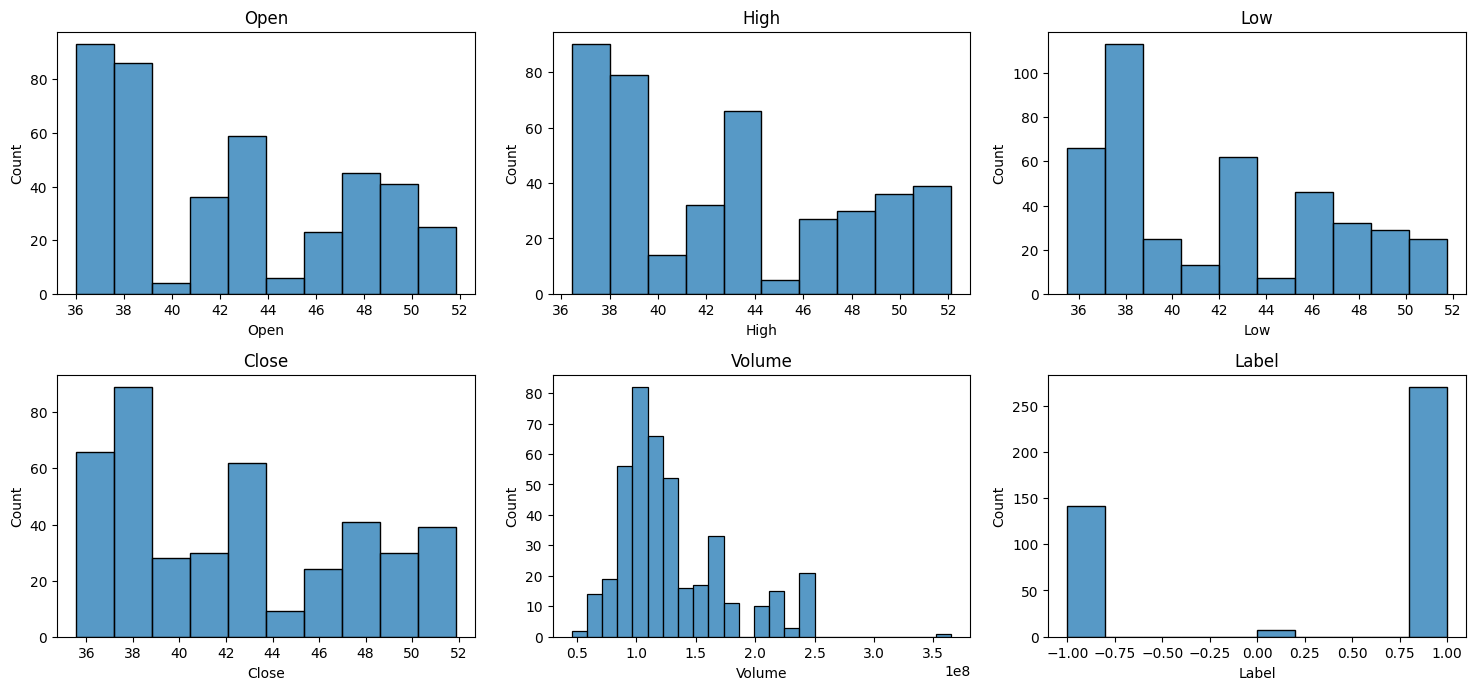

In [ ]:
#creating histograms for all columns with numerical data type for univariate analysis

plt.figure(figsize=(15,10))

features = data.select_dtypes(include=['number']).columns.tolist()

for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)   #create subplots in main plot
    sns.histplot(data=data, x=feature)
    plt.title(feature)

plt.tight_layout()   # adjust spacing
plt.show()

Th above histograms show bimodal or mutlitmodal distrubition across some features.

**Visualizing the distribution of sentiment, positive, negetive, neutral accross entries**

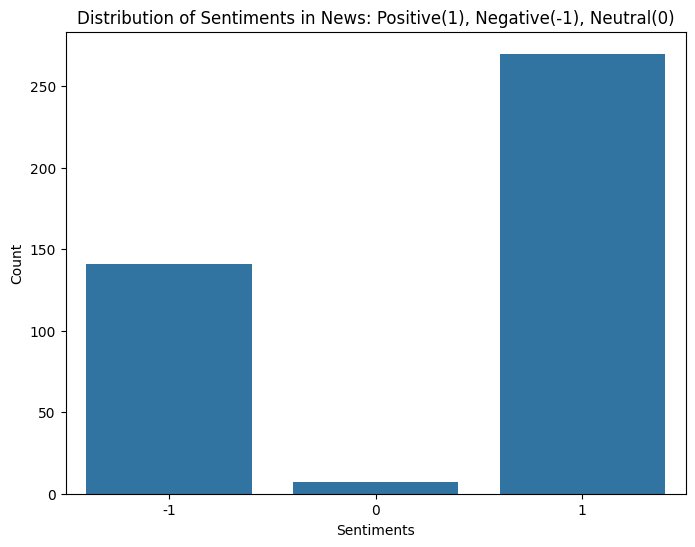

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Label')
plt.title("Distribution of Sentiments in News: Positive(1), Negative(-1), Neutral(0)")
plt.xlabel('Sentiments')
plt.ylabel("Count")
plt.show()

The dataset contains majority of positive reviews(more than 250), about 150 Negetive reviews and very few neutral reviews

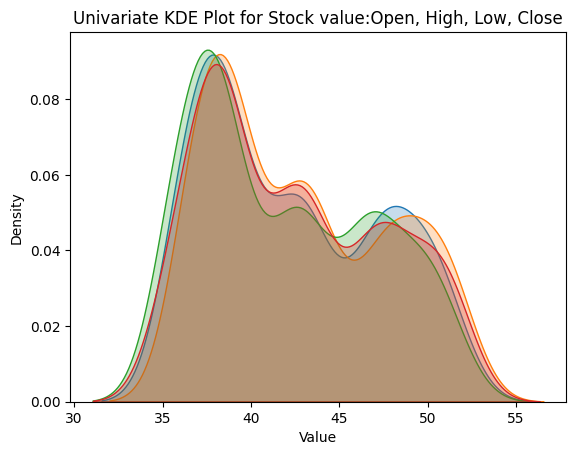

In [ ]:
# Create KDE plot for Open , high , low, closing values of stocks
sns.kdeplot(data=data, x="Open", fill=True)
sns.kdeplot(data=data, x="High", fill=True)
sns.kdeplot(data=data, x="Low", fill=True)
sns.kdeplot(data=data, x="Close", fill=True)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Univariate KDE Plot for Stock value:Open, High, Low, Close")
plt.show()

KDE plot shows a highly overlapping distributions, indication strong corelation between them. There is slight right skwed.

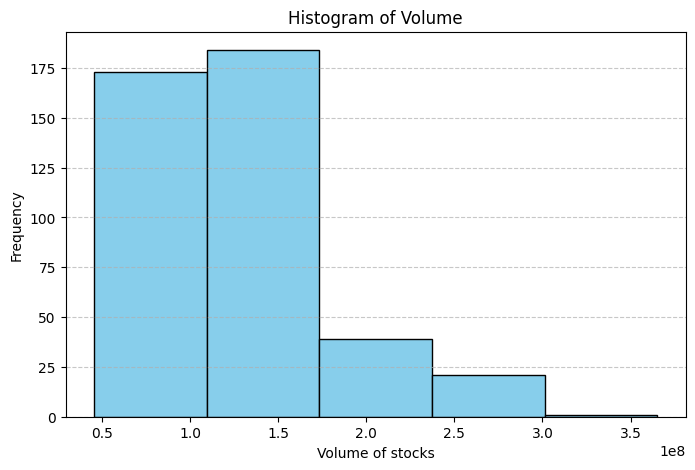

In [ ]:
#plotting histogram on Volume
plt.figure(figsize=(8, 5))
plt.hist(data['Volume'], bins=5, color='skyblue', edgecolor='black')
plt.title("Histogram of Volume")
plt.xlabel("Volume of stocks")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Right Skewed distribution, most trading days have moderate volume, but some trading days have extremely high volume

**Distribution of length of News Articles by word count and character count**

---



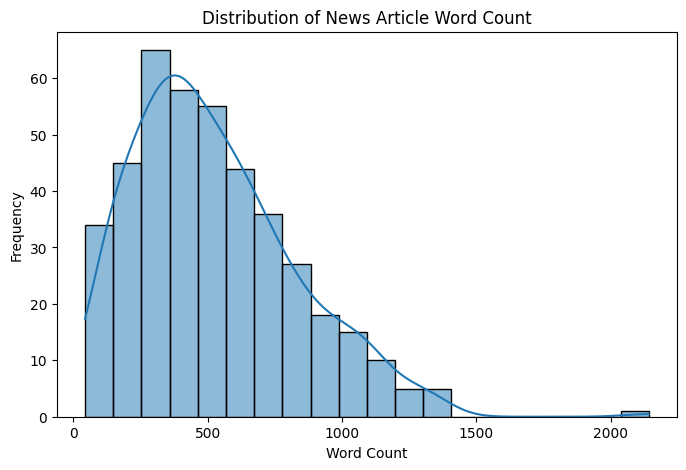

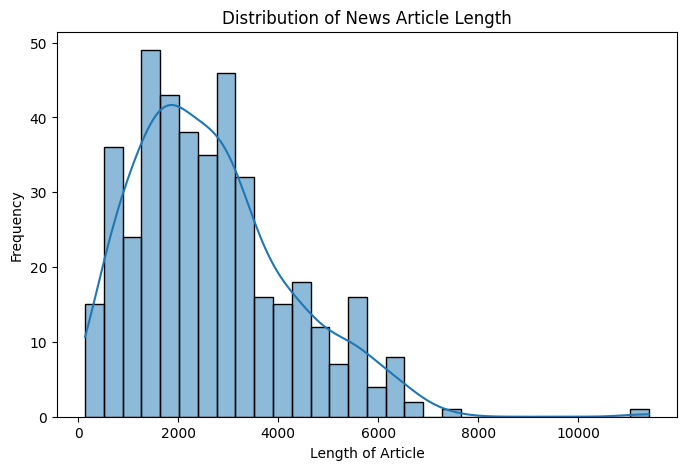

In [ ]:
# Calculting the length of News articles and checking the distrubution of length of news articles
data['news_length']=data['News'].apply(lambda x:len(str(x).split(' ')))
data['news_character_length']=data['News'].apply(lambda x: len(str(x)))

#plot for word count
plt.figure(figsize=(8,5))
sns.histplot(data['news_length'], bins=20, kde=True)
plt.title("Distribution of News Article Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#plot for character count
plt.figure(figsize=(8,5))
sns.histplot(data['news_character_length'], bins=30, kde=True)
plt.title("Distribution of News Article Length")
plt.xlabel("Length of Article")
plt.ylabel("Frequency")
plt.show()

In [ ]:
data['news_length'].describe() # to find stistical summary of length of news articles for sentimental analysis

,news_length
count,418.000000
mean,525.662679
std,303.584080
min,44.000000
25%,304.250000
50%,480.000000
75%,700.500000
max,2142.000000


The distribution is Right skewed, most News articles have moderate to fewer words. Very few articles have longer length. Can check if any correlation with sentiments labels.The mean of length of articles is 525 words



### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

### Date vs Price

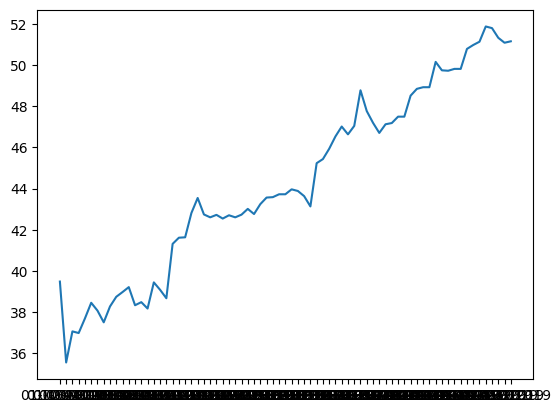

In [ ]:
plt.plot(data['Date'], data['Close']) #to check the trend of closing stock over time

positive corelation

In [ ]:
data.groupby('Date')['Label'].mean() #to check sentiment changes to positive over time


,Label
Date,
01-02-2019,-0.142857
01-03-2019,-0.405405
01-04-2019,0.187500
01-07-2019,0.076923
01-08-2019,0.733333
...,...
04-23-2019,0.600000
04-24-2019,0.666667
04-25-2019,1.000000


Sentiment changes towards positive over time

In [ ]:
data['Return_value'] = (data['Close'] - data['Open'])/ data['Open'] #calculating return value
data['Volatility'] = data['High'] - data['Low'] #Calculating the amount of change in stock value
data[['Return_value','Volatility']].describe()

,Return_value,Volatility
count,418.000000,418.000000
mean,0.002550,0.863589
std,0.012198,0.350074
min,-0.025459,0.330000
25%,-0.005569,0.585000
50%,0.001926,0.835000
75%,0.012203,1.100000
max,0.026521,2.070000


,Open,High,Low,Close,Volume,Return_value,Volatility
Date,,,,,,,
01-02-2019,38.72,39.71,38.56,39.48,130672400.0,0.019628,1.15
01-03-2019,35.99,36.43,35.50,35.55,103544800.0,-0.012226,0.93
01-04-2019,36.13,37.14,35.95,37.06,111448000.0,0.025740,1.19
01-07-2019,37.17,37.21,36.47,36.98,109012000.0,-0.005112,0.74
01-08-2019,37.39,37.96,37.13,37.69,216071600.0,0.008024,0.83


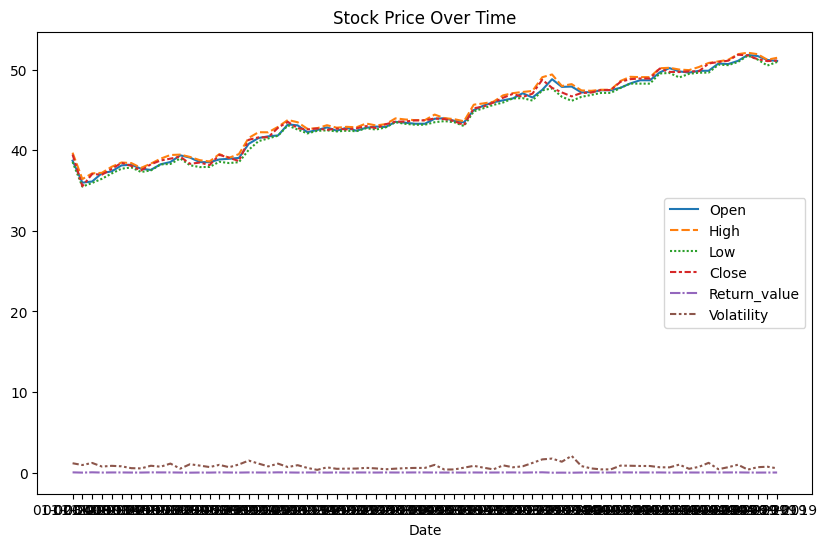

In [ ]:
#Aggregating data of stocks by date
stock_daily= data.groupby('Date').agg({'Open': 'mean', 'High': 'mean', 'Low': 'mean', 'Close': 'mean', 'Volume': 'mean', 'Return_value': 'mean', 'Volatility': 'mean'}).reset_index()
stock_daily.set_index('Date', inplace=True)

plt.figure(figsize=(10,6))
sns.lineplot(stock_daily.drop('Volume', axis=1));
plt.title('Stock Price Over Time')
stock_daily.head()

In [ ]:
data['Date'] = pd.to_datetime(data['Date']) # to process date
data['Year'] = data['Date'].dt.year

###Volume vs Close price

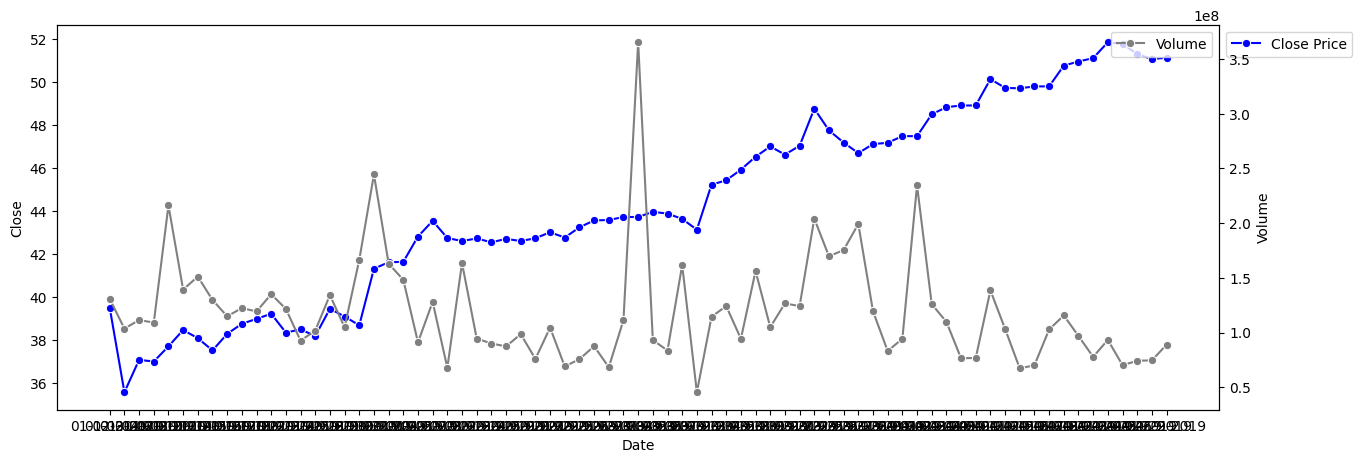

In [ ]:
#Volume vs close price
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

### Sentiment vs News length

<Axes: xlabel='Label', ylabel='news_length'>

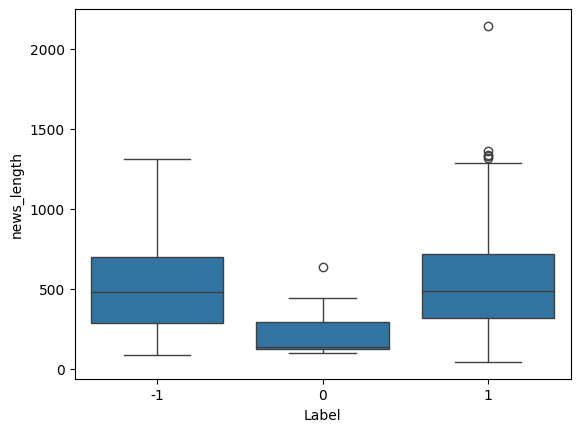

In [ ]:
sns.boxplot(x='Label', y='news_length', data=data) #to check Sentiment vs News length

Box plot shows that, news articles are typically shorter have neutral impact.
News articles with longer word count have eith positive or negative impact.
News articles with Postive sentiment have some outliers, article with 2000 or more word count.




### Sentiment vs Price

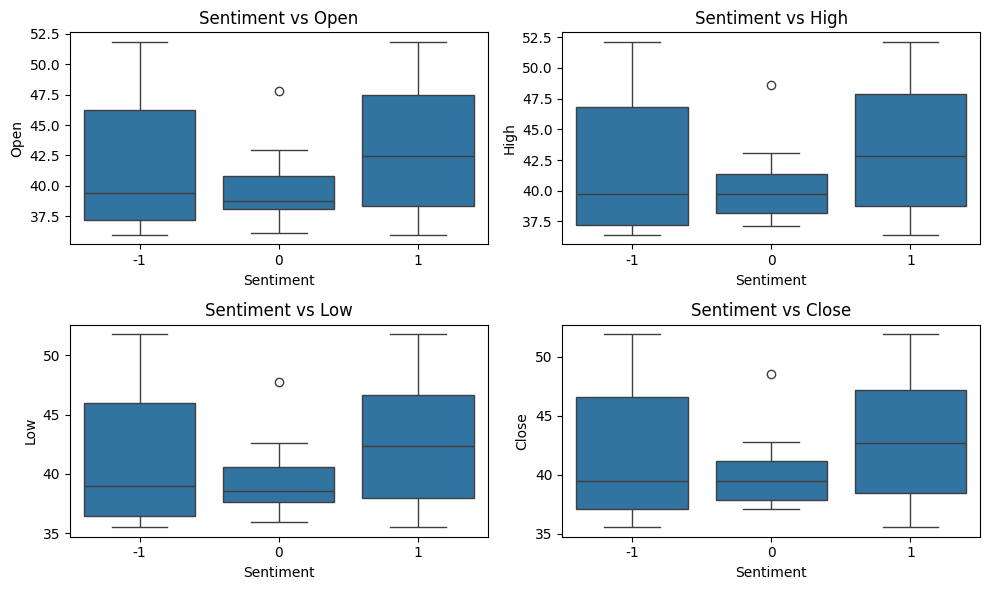

In [ ]:
plt.figure(figsize=(10, 6))

for i in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i[0]+1)
    sns.boxplot(x='Label', y=i[1], data=data)
    plt.title(f'Sentiment vs {i[1]}')
    plt.xlabel('Sentiment')
    plt.tight_layout()

plt.show()

<Axes: xlabel='Label', ylabel='Return_value'>

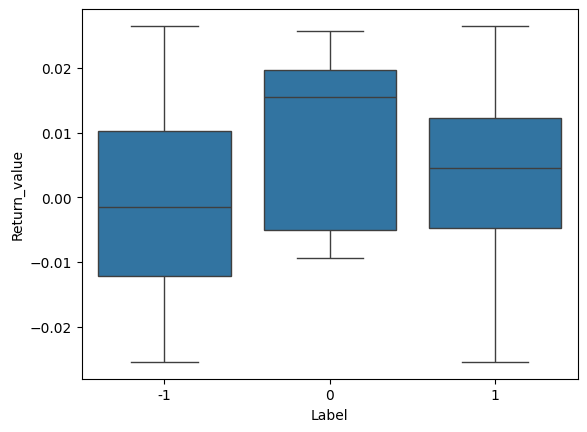

In [ ]:
sns.boxplot(x='Label', y='Return_value', data=data)

###Sentiment vs Volume


<Axes: xlabel='Label', ylabel='Volume'>

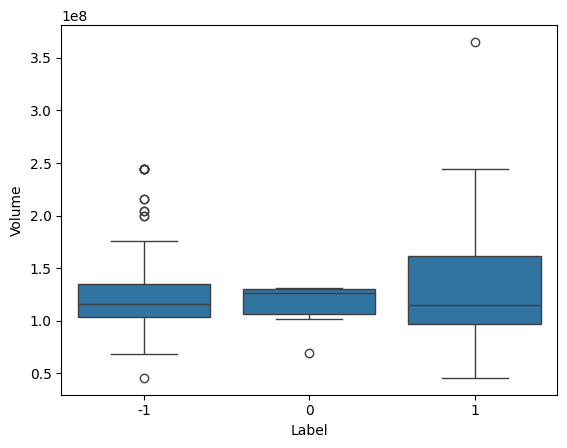

In [ ]:
sns.boxplot(x='Label', y='Volume', data=data)

###Correlation HeatMap

<Axes: >

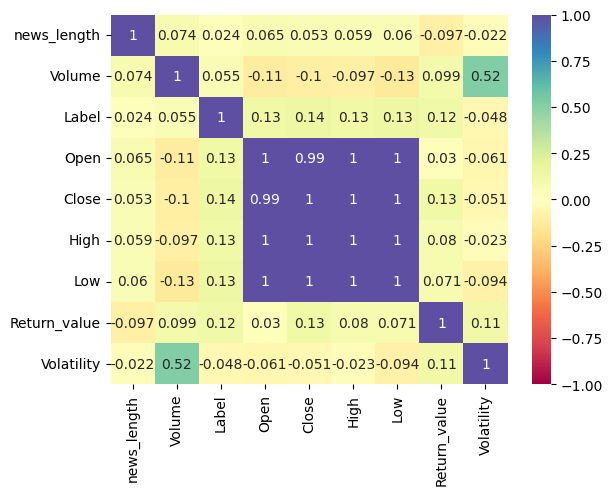

In [ ]:
sns.heatmap(data[['news_length','Volume','Label','Open','Close','High','Low','Return_value','Volatility']].corr(),vmin=-1,vmax=1, annot=True, cmap='Spectral')

There is some positive correlation between New article length and high volume trading days.
There is negative correlationship between News Article length and low Return values, indicating longer articles and negative sentiment correlation

## **Data Preprocessing**

In [ ]:
data['Date'].describe()

,Date
count,418
mean,2019-02-14 12:24:06.889952256
min,2019-01-02 00:00:00
25%,2019-01-11 00:00:00
50%,2019-01-31 00:00:00
75%,2019-03-21 00:00:00
max,2019-04-29 00:00:00


In [ ]:
data = data.sort_values(by='Date', ascending=True).reset_index(drop=True)
print("First 5 rows of the sorted DataFrame:")
print(data.head())
print("\nLast 5 rows of the sorted DataFrame:")
print(data.tail())

First 5 rows of the sorted DataFrame:
        Date                                               News   Open   High  \
0 2019-01-02  The dollar minutes ago tumbled to  106 67 from...  38.72  39.71   
1 2019-01-02  By Kate Duguid NEW YORK  Reuters    Yields on ...  38.72  39.71   
2 2019-01-02  Apple s  NASDAQ AAPL  Tim Cook appears on CNBC...  38.72  39.71   
3 2019-01-02  Citing weaker than hoped iPhone revenue  Apple...  38.72  39.71   
4 2019-01-02  The tech sector  NYSEARCA XLK  plunges 2 3  af...  38.72  39.71   

     Low  Close     Volume  Label  news_length  news_character_length  \
0  38.56  39.48  130672400      1          161                    607   
1  38.56  39.48  130672400     -1          581                   2920   
2  38.56  39.48  130672400      1          176                    862   
3  38.56  39.48  130672400     -1           90                    381   
4  38.56  39.48  130672400     -1           92                    346   

   Return_value  Volatility  Year  


### Our Data set is small. Split the data DataFrame into an initial training set (90%) and a test set (10%), while maintiaing chronological order so that we use older data to train and nwer to test

In [ ]:
train_size = int(len(data) * 0.9)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print(f"Shape of training data: {train_data.shape}")
print(f"Shape of test data: {test_data.shape}")
print(f"Date range of training data: {train_data['Date'].min()} to {train_data['Date'].max()}")
print(f"Date range of test data: {test_data['Date'].min()} to {test_data['Date'].max()}")

Shape of training data: (376, 13)
Shape of test data: (42, 13)
Date range of training data: 2019-01-02 00:00:00 to 2019-04-15 00:00:00
Date range of test data: 2019-04-15 00:00:00 to 2019-04-29 00:00:00


### Dividing data into a training set (Because our Data set too small - 90% of the initial training data) and a validation set (10% of the initial training data).

In [ ]:
train_val_size = int(len(train_data) * 0.90);
new_train_data = train_data.iloc[:train_val_size];
val_data = train_data.iloc[train_val_size:];

print(f"Shape of new training data: {new_train_data.shape}");
print(f"Shape of validation data: {val_data.shape}");
print(f"Date range of new training data: {new_train_data['Date'].min()} to {new_train_data['Date'].max()}");
print(f"Date range of validation data: {val_data['Date'].min()} to {val_data['Date'].max()}");

Shape of new training data: (338, 13)
Shape of validation data: (38, 13)
Date range of new training data: 2019-01-02 00:00:00 to 2019-03-26 00:00:00
Date range of validation data: 2019-03-27 00:00:00 to 2019-04-15 00:00:00


In [ ]:
#for sake of code readability changing train/test data to X_train and X_test
X_train=new_train_data
X_test=test_data

In [ ]:
# Completing the code to pick the 'Label' column as the target variable
y_train = X_train["Label"].copy()
y_test = X_test["Label"].copy()

print("Train label shape",y_train.shape)
print("Test label shape ",y_test.shape)

Train label shape (338,)
Test label shape  (42,)


## **Word Embeddings**

#### **Word2Vec**

Text prepration
use simple_preprocess function from gensim.utils to lowercase all words in News column, remove punctutation and tokenize the text.

In [ ]:
data_W2v=data.copy() #creating a duplicate data set to not modify the original

In [ ]:
from gensim.utils import simple_preprocess
data_W2v['tokens'] = data_W2v['News'].apply(lambda x: simple_preprocess(x))


Train the word2vec model preprocessed data
to capture the vocabulary, context and relation ships.

In [ ]:
model_word2vec=Word2Vec(sentences=data_W2v['tokens'],vector_size = 300, min_count = 1, window=5, workers = 6, seed=42)

In [ ]:
#Checking the length of vocabulary
model_word2vec.wv.vectors.shape

(11705, 300)

Apply simple process to our trainins and testing data

In [ ]:
from gensim.utils import simple_preprocess

# Apply simple_preprocess to the 'News' column of X_train
X_train['tokens'] = X_train['News'].apply(lambda x: simple_preprocess(x))

# Apply simple_preprocess to the 'News' column of X_test
X_test['tokens'] = X_test['News'].apply(lambda x: simple_preprocess(x))

print("X_train with tokens:")
print(X_train.head())
print("\nX_test with tokens:")
print(X_test.head())

X_train with tokens:
        Date                                               News   Open   High  \
0 2019-01-02  The dollar minutes ago tumbled to  106 67 from...  38.72  39.71   
1 2019-01-02  By Kate Duguid NEW YORK  Reuters    Yields on ...  38.72  39.71   
2 2019-01-02  Apple s  NASDAQ AAPL  Tim Cook appears on CNBC...  38.72  39.71   
3 2019-01-02  Citing weaker than hoped iPhone revenue  Apple...  38.72  39.71   
4 2019-01-02  The tech sector  NYSEARCA XLK  plunges 2 3  af...  38.72  39.71   

     Low  Close     Volume  Label  news_length  news_character_length  \
0  38.56  39.48  130672400      1          161                    607   
1  38.56  39.48  130672400     -1          581                   2920   
2  38.56  39.48  130672400      1          176                    862   
3  38.56  39.48  130672400     -1           90                    381   
4  38.56  39.48  130672400     -1           92                    346   

   Return_value  Volatility  Year  \
0      0.019628 

Average the vectors

In [ ]:
def document_vector(tokens, model):
    """
    Averages the Word2Vec word vectors for a list of tokens to create a document vector.

    Parameters:
    tokens (list): A list of preprocessed tokens (words).
    model (gensim.models.Word2Vec): The trained Word2Vec model.

    Returns:
    numpy.ndarray: The averaged document vector or a zero vector if no valid tokens.
    """
    # Filter out tokens not present in the model's vocabulary
    valid_tokens = [token for token in tokens if token in model.wv.key_to_index]

    if valid_tokens:
        # Retrieve word vectors and calculate their mean
        doc_vector = np.mean(model.wv[valid_tokens], axis=0)
    else:
        # Return a zero vector if no valid tokens are found
        doc_vector = np.zeros(model.vector_size)
    return doc_vector

# Apply the function to create Word2Vec embeddings for X_train
X_train['word2vec_embeddings_news'] = X_train['tokens'].apply(lambda x: document_vector(x, model_word2vec))

# Apply the function to create Word2Vec embeddings for X_test
X_test['word2vec_embeddings_news'] = X_test['tokens'].apply(lambda x: document_vector(x, model_word2vec))

print("Shape of Word2Vec embeddings for X_train:", np.array(X_train['word2vec_embeddings_news'].to_list()).shape)
print("Shape of Word2Vec embeddings for X_test:", np.array(X_test['word2vec_embeddings_news'].to_list()).shape)
print("\nFirst 5 rows of X_train with new embeddings:")
print(X_train[['News', 'tokens', 'word2vec_embeddings_news']].head())
print("\nFirst 5 rows of X_test with new embeddings:")
print(X_test[['News', 'tokens', 'word2vec_embeddings_news']].head())

Shape of Word2Vec embeddings for X_train: (338, 300)
Shape of Word2Vec embeddings for X_test: (42, 300)

First 5 rows of X_train with new embeddings:
                                                News  \
0  The dollar minutes ago tumbled to  106 67 from...   
1  By Kate Duguid NEW YORK  Reuters    Yields on ...   
2  Apple s  NASDAQ AAPL  Tim Cook appears on CNBC...   
3  Citing weaker than hoped iPhone revenue  Apple...   
4  The tech sector  NYSEARCA XLK  plunges 2 3  af...   

                                              tokens  \
0  [the, dollar, minutes, ago, tumbled, to, from,...   
1  [by, kate, duguid, new, york, reuters, yields,...   
2  [apple, nasdaq, aapl, tim, cook, appears, on, ...   
3  [citing, weaker, than, hoped, iphone, revenue,...   
4  [the, tech, sector, nysearca, xlk, plunges, af...   

                            word2vec_embeddings_news  
0  [-0.022195837, -0.1703709, -0.122205295, -0.03...  
1  [-0.06830816, -0.23853719, -0.2193286, -0.0430...  
2  [-0.0550

### **Sentence Transformer**

Generating Sentence transformer embeddings

In [ ]:
model_sentence = SentenceTransformer('all-MiniLM-L6-v2')

# Generate Sentence Transformer embeddings for X_train
X_train['sentence_embeddings_news'] = X_train['News'].apply(lambda x: model_sentence.encode(x))

# Generate Sentence Transformer embeddings for X_test
X_test['sentence_embeddings_news'] = X_test['News'].apply(lambda x: model_sentence.encode(x))

print("Shape of Sentence Transformer embeddings for X_train:", np.array(X_train['sentence_embeddings_news'].to_list()).shape)
print("Shape of Sentence Transformer embeddings for X_test:", np.array(X_test['sentence_embeddings_news'].to_list()).shape)
print("\nFirst 5 rows of X_train with Sentence Transformer embeddings:")
print(X_train[['News', 'sentence_embeddings_news']].head())
print("\nFirst 5 rows of X_test with Sentence Transformer embeddings:")
print(X_test[['News', 'sentence_embeddings_news']].head())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Shape of Sentence Transformer embeddings for X_train: (338, 384)
Shape of Sentence Transformer embeddings for X_test: (42, 384)

First 5 rows of X_train with Sentence Transformer embeddings:
                                                News  \
0  The dollar minutes ago tumbled to  106 67 from...   
1  By Kate Duguid NEW YORK  Reuters    Yields on ...   
2  Apple s  NASDAQ AAPL  Tim Cook appears on CNBC...   
3  Citing weaker than hoped iPhone revenue  Apple...   
4  The tech sector  NYSEARCA XLK  plunges 2 3  af...   

                            sentence_embeddings_news  
0  [-0.0835015, 0.0072796065, 0.021808175, 0.0286...  
1  [-0.0899501, 0.004793213, 0.028068338, 0.02377...  
2  [0.00054710807, -0.018766575, 0.03320355, 0.01...  
3  [0.015627066, 0.018478882, 0.047017485, 0.0086...  
4  [0.0066152248, -0.022560896, 0.042322926, -0.0...  

First 5 rows of X_test with Sentence Transformer embeddings:
                                                  News  \
376  By Yimou Lee TAIP

## **Sentiment Analysis**

### **Model Evaluation Criterion**

**Note:**  
You can use the helper functions provided below to:
- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)

These are ready-to-use. However, you’re welcome to explore and write your own evaluation code if you prefer. Feel free to modify or extend these as per your learning goals!

##### **Utility Functions**

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

   Accuracy    Recall  Precision        F1
0  0.701183  0.701183   0.767421  0.631681


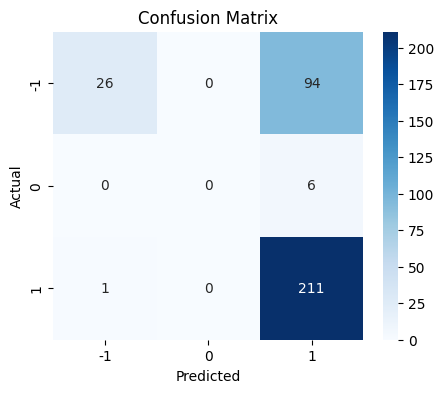

Random Forest Classifier with Word2Vec Embeddings:


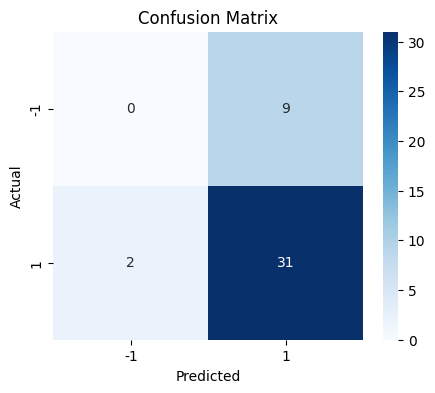

   Accuracy    Recall  Precision        F1
0  0.738095  0.738095   0.608929  0.667319


In [ ]:
X_train_word2vec = np.array(X_train['word2vec_embeddings_news'].to_list())
X_test_word2vec = np.array(X_test['word2vec_embeddings_news'].to_list())

rf_word2vec = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=3)

# fit the model on training data
rf_word2vec.fit(X_train_word2vec, y_train)

#predicting on traininf and testing data
y_pred_train = rf_word2vec.predict(X_train_word2vec)
y_pred_test = rf_word2vec.predict(X_test_word2vec)

#Confusion matrix
#metrics on training data
rf_word2vec_metrics_train = model_performance_classification_sklearn(y_train, y_pred_train)
print(rf_word2vec_metrics_train)
plot_confusion_matrix(y_train,y_pred_train)


print("Random Forest Classifier with Word2Vec Embeddings:")
plot_confusion_matrix(y_test, y_pred_test)

#metrics on test data
rf_word2vec_metrics = model_performance_classification_sklearn(y_test, y_pred_test)
print(rf_word2vec_metrics)

# Store metrics for summary
rf_word2vec_metrics_train['Model'] = 'RandomForest_Word2Vec_Train'
rf_word2vec_metrics['Model'] = 'RandomForest_Word2Vec_Test'

### **Build Random Forest Models using different text embeddings**



ramdom forest model- using text embeddings from word2vec

   Accuracy    Recall  Precision        F1
0  0.701183  0.701183   0.767421  0.631681


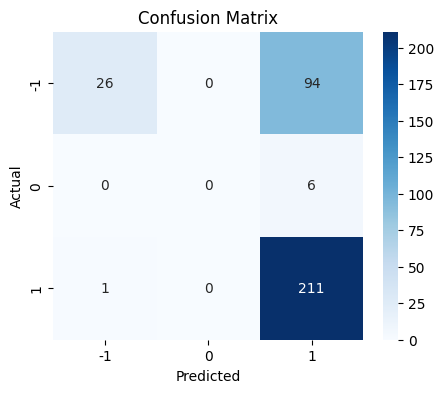

Random Forest Classifier with Word2Vec Embeddings:


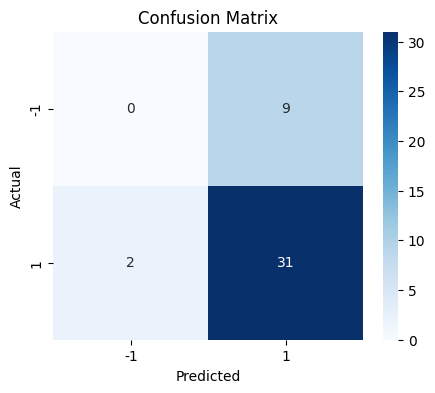

   Accuracy    Recall  Precision        F1
0  0.738095  0.738095   0.608929  0.667319


In [ ]:
X_train_word2vec = np.array(X_train['word2vec_embeddings_news'].to_list())
X_test_word2vec = np.array(X_test['word2vec_embeddings_news'].to_list())

rf_word2vec = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=3)

# fit the model on training data
rf_word2vec.fit(X_train_word2vec, y_train)

#predicting on traininf and testing data
y_pred_train = rf_word2vec.predict(X_train_word2vec)
y_pred_test = rf_word2vec.predict(X_test_word2vec)

#Confusion matrix
#metrics on training data
rf_word2vec_metrics_train = model_performance_classification_sklearn(y_train, y_pred_train)
print(rf_word2vec_metrics_train)
plot_confusion_matrix(y_train,y_pred_train)


print("Random Forest Classifier with Word2Vec Embeddings:")
plot_confusion_matrix(y_test, y_pred_test)

#metrics on test data
rf_word2vec_metrics = model_performance_classification_sklearn(y_test, y_pred_test)
print(rf_word2vec_metrics)

# Store metrics for summary
rf_word2vec_metrics_train['Model'] = 'RandomForest_Word2Vec_Train'
rf_word2vec_metrics['Model'] = 'RandomForest_Word2Vec_Test'

Random Forest Classifier with Sentence Transformer Embeddings (Training Data):
   Accuracy    Recall  Precision        F1
0  0.795858  0.795858   0.823803  0.767909


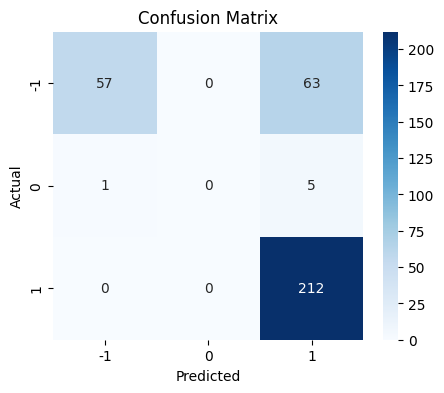


Random Forest Classifier with Sentence Transformer Embeddings (Test Data):
   Accuracy    Recall  Precision        F1
0  0.785714  0.785714   0.617347  0.691429


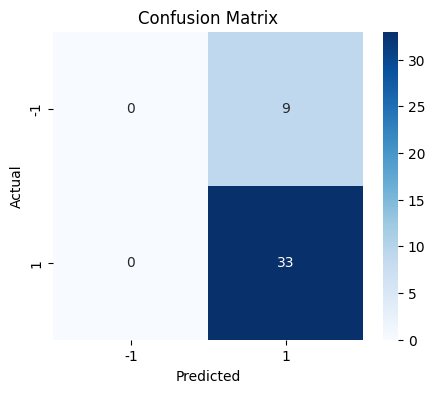

In [ ]:
# Extract Sentence Transformer embeddings
X_train_sentence = np.array(X_train['sentence_embeddings_news'].to_list())
X_test_sentence = np.array(X_test['sentence_embeddings_news'].to_list())

# Initialize and train RandomForestClassifier
rf_sentence = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=3)
rf_sentence.fit(X_train_sentence, y_train)

# Make predictions
y_pred_train_sentence = rf_sentence.predict(X_train_sentence)
y_pred_test_sentence = rf_sentence.predict(X_test_sentence)

# Evaluate performance
print("Random Forest Classifier with Sentence Transformer Embeddings (Training Data):")
rf_sentence_metrics_train = model_performance_classification_sklearn(y_train, y_pred_train_sentence)
print(rf_sentence_metrics_train)
plot_confusion_matrix(y_train, y_pred_train_sentence)

print("\nRandom Forest Classifier with Sentence Transformer Embeddings (Test Data):")
rf_sentence_metrics = model_performance_classification_sklearn(y_test, y_pred_test_sentence)
print(rf_sentence_metrics)
plot_confusion_matrix(y_test, y_pred_test_sentence)

# Store metrics for summary
rf_sentence_metrics_train['Model'] = 'RandomForest_Sentence_Train'
rf_sentence_metrics['Model'] = 'RandomForest_Sentence_Test'

### **Building Neural Network Models using different text embeddings**

Neural Network model using embedding from word2vec

In [ ]:
# Map original labels (-1, 0, 1) to (0, 1, 2)
y_train_nn = y_train.map({-1: 0, 0: 1, 1: 2})
y_test_nn = y_test.map({-1: 0, 0: 1, 1: 2})

# Prepare Word2Vec embeddings for validation data
val_data['tokens'] = val_data['News'].apply(lambda x: simple_preprocess(x))
X_val_word2vec = np.array(val_data['tokens'].apply(lambda x: document_vector(x, model_word2vec)).to_list())
y_val_nn = val_data['Label'].map({-1: 0, 0: 1, 1: 2})

print("Shape of y_train_nn:", y_train_nn.shape)
print("Shape of y_test_nn:", y_test_nn.shape)
print("Shape of X_val_word2vec:", X_val_word2vec.shape)
print("Shape of y_val_nn:", y_val_nn.shape)

Shape of y_train_nn: (338,)
Shape of y_test_nn: (42,)
Shape of X_val_word2vec: (38, 300)
Shape of y_val_nn: (38,)


Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6033 - loss: 0.8496 - val_accuracy: 0.6579 - val_loss: 0.7708
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6112 - loss: 0.7304 - val_accuracy: 0.6579 - val_loss: 0.7498
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6405 - loss: 0.7246 - val_accuracy: 0.6579 - val_loss: 0.7309
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6405 - loss: 0.7249 - val_accuracy: 0.6579 - val_loss: 0.7361
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6335 - loss: 0.7298 - val_accuracy: 0.6579 - val_loss: 0.7288
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6405 - loss: 0.7169 - val_accuracy: 0.6579 - val_loss: 0.7241
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6405 - loss: 0.7176 - val_accuracy: 0.6579 - val_loss: 0.7279
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6350 - loss: 0.7239 - val_accuracy: 0.7105 - val_loss

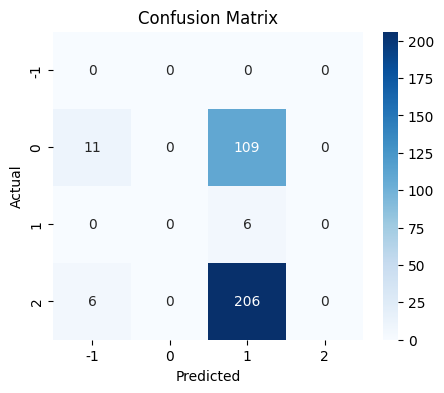


Neural Network with Word2Vec Embeddings (Test Data):
   Accuracy    Recall  Precision        F1
0  0.738095  0.738095   0.608929  0.667319


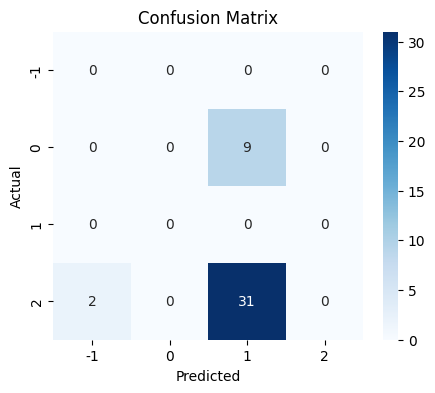

In [ ]:
from sklearn.utils import class_weight
import numpy as np
import gc # Import garbage collection module
import tensorflow as tf

tf.keras.backend.clear_session()
# Explicitly call garbage collection after training (or within epochs if needed)
gc.collect()

# Define the Neural Network model
model_word2vec_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_word2vec.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax') # 3 classes: negative, neutral, positive
])

# Compile the model
model_word2vec_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

'''# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)
class_weight_dict = dict(enumerate(class_weights))'''

# Train the model with class weights
history_word2vec_nn = model_word2vec_nn.fit(
    X_train_word2vec, y_train_nn,
    epochs=50,
    batch_size=20,
    validation_data=(X_val_word2vec, y_val_nn),
    #class_weight=class_weight_dict,  # Apply class weights here
    verbose=1 #displays a progress bar
)



# Evaluate the model on the test data
'''
loss_word2vec_nn, accuracy_word2vec_nn = model_word2vec_nn.evaluate(X_test_word2vec, y_test_nn, verbose=0)
print(f"\nNeural Network with Word2Vec Embeddings - Test Accuracy: {accuracy_word2vec_nn:.4f}")
'''
#check training performance
y_train_pred_prob_word2vec_nn = model_word2vec_nn.predict(X_train_word2vec)
y_train_pred_class_word2vec_nn = np.argmax(y_train_pred_prob_word2vec_nn,axis=1)

# Make predictions
y_pred_prob_word2vec_nn = model_word2vec_nn.predict(X_test_word2vec)
y_pred_class_word2vec_nn = np.argmax(y_pred_prob_word2vec_nn, axis=1)

# Convert predictions back to original labels (-1, 0, 1)
y_train_original_word2vec_nn = pd.Series(y_train_pred_class_word2vec_nn).map({0: -1, 1: 0, 2: 1}).values
y_pred_original_word2vec_nn = pd.Series(y_pred_class_word2vec_nn).map({0: -1, 1: 0, 2: 1}).values

# Display performance metrics
print("\nNeural Network with Word2Vec Embeddings (Training Data):")
metrics_word2vec_nn_train = model_performance_classification_sklearn(y_train, y_train_original_word2vec_nn)
print(metrics_word2vec_nn_train)
plot_confusion_matrix(y_train_nn, y_train_original_word2vec_nn)


print("\nNeural Network with Word2Vec Embeddings (Test Data):")
metrics_word2vec_nn = model_performance_classification_sklearn(y_test, y_pred_original_word2vec_nn)
print(metrics_word2vec_nn)
plot_confusion_matrix(y_test_nn, y_pred_original_word2vec_nn)

# Store metrics for summary
rf_word2vec_metrics_train['Model'] = 'RandomForest_Word2Vec_Train'
rf_word2vec_metrics['Model'] = 'RandomForest_Word2Vec_Test'
metrics_word2vec_nn['Model'] = 'NN_Word2Vec_Test'
metrics_word2vec_nn_train['Model'] = 'NN_Word2Vec_Train'

Building Neural Network Model from Sentence embeddings

In [ ]:
# Prepare Sentence Transformer embeddings for validation data
val_data['sentence_embeddings_news'] = val_data['News'].apply(lambda x: model_sentence.encode(x))
X_val_sentence = np.array(val_data['sentence_embeddings_news'].to_list())
y_val_nn_sentence = val_data['Label'].map({-1: 0, 0: 1, 1: 2})

print("Shape of X_val_sentence:", X_val_sentence.shape)
print("Shape of y_val_nn_sentence:", y_val_nn_sentence.shape)

Shape of X_val_sentence: (38, 384)
Shape of y_val_nn_sentence: (38,)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5755 - loss: 1.0478 - val_accuracy: 0.6053 - val_loss: 0.8917
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5903 - loss: 0.9910 - val_accuracy: 0.6053 - val_loss: 0.9360
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6222 - loss: 0.8943 - val_accuracy: 0.6579 - val_loss: 0.9110
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5658 - loss: 0.8814 - val_accuracy: 0.6053 - val_loss: 0.8554
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6776 - loss: 0.8312 - val_accuracy: 0.6579 - val_loss: 0.8451
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6214 - loss: 0.8174 - val_accuracy: 0.6053 - val_loss: 0.8081
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6050 - loss: 0.7259 - val_accuracy: 0.6579 - val_loss: 0.7500
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6167 - loss: 0.7071 - val_accuracy: 0.6053 - 

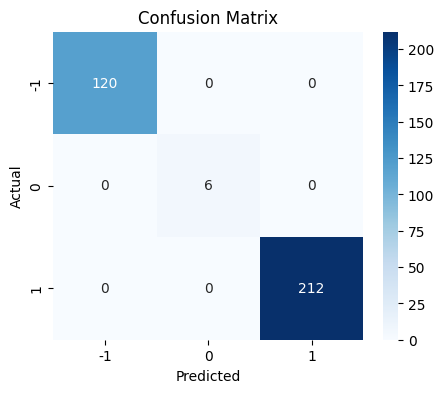

   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

Neural Network with Sentence Transformer Embeddings (Test Data):


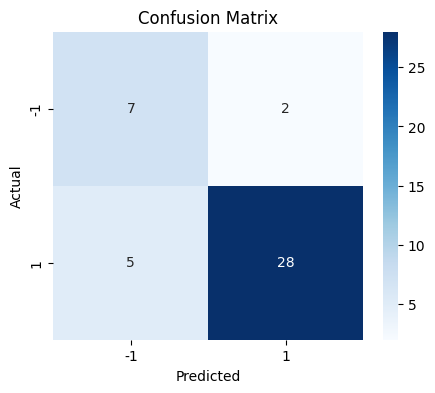

   Accuracy    Recall  Precision       F1
0  0.833333  0.833333   0.858333  0.84127


In [ ]:
# Define the Neural Network model for Sentence Transformer embeddings
tf.keras.backend.clear_session()
# Explicitly call garbage collection after training (or within epochs if needed)
gc.collect()

model_sentence_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sentence.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='leaky_relu'),
    Dropout(0.2),
    Dense(64, activation='tanh'),
    Dropout(0.2),
    Dense(3, activation='softmax') # 3 classes: negative, neutral, positive
])

# Compile the model
model_sentence_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Calculate class weights (using the same weights as for Word2Vec NN as the labels are the same)
# This assumes the class distribution in y_train is the same for both models
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)
class_weight_dict = dict(enumerate(class_weights))

# Train the model with class weights
history_sentence_nn = model_sentence_nn.fit(
    X_train_sentence, y_train_nn,
    epochs=100,
    batch_size=20,
    validation_data=(X_val_sentence, y_val_nn_sentence),
    class_weight=class_weight_dict, # Apply class weights here
    verbose=1
)

# Evaluate the model on the test data
loss_sentence_nn, accuracy_sentence_nn = model_sentence_nn.evaluate(X_test_sentence, y_test_nn, verbose=0)
print(f"\nNeural Network with Sentence Transformer Embeddings - Test Accuracy: {accuracy_sentence_nn:.4f}")

# Check training performance
y_train_pred_prob_sentence_nn = model_sentence_nn.predict(X_train_sentence)
y_train_pred_class_sentence_nn = np.argmax(y_train_pred_prob_sentence_nn, axis=1)

# Make predictions
y_pred_prob_sentence_nn = model_sentence_nn.predict(X_test_sentence)
y_pred_class_sentence_nn = np.argmax(y_pred_prob_sentence_nn, axis=1)

# Convert predictions back to original labels (-1, 0, 1)
y_train_original_sentence_nn = pd.Series(y_train_pred_class_sentence_nn).map({0: -1, 1: 0, 2: 1}).values
y_pred_original_sentence_nn = pd.Series(y_pred_class_sentence_nn).map({0: -1, 1: 0, 2: 1}).values

# Display performance metrics
print("\nNeural Network with Sentence Transformer Embeddings (Training Data):")
plot_confusion_matrix(y_train, y_train_original_sentence_nn)
metrics_sentence_nn_train = model_performance_classification_sklearn(y_train, y_train_original_sentence_nn)
print(metrics_sentence_nn_train)

print("\nNeural Network with Sentence Transformer Embeddings (Test Data):")
plot_confusion_matrix(y_test, y_pred_original_sentence_nn)
metrics_sentence_nn = model_performance_classification_sklearn(y_test, y_pred_original_sentence_nn)
print(metrics_sentence_nn)

# Store metrics for summary
metrics_sentence_nn_train['Model'] = 'NN_Sentence_Train'
metrics_sentence_nn['Model'] = 'NN_Sentence_Test'

### **Model Performance Summary and Final Model Selection**

In [ ]:
#conactenate the training performance metrics from differernt moels into single DataFrame
all_metrics = pd.concat([
    rf_word2vec_metrics_train,
    rf_word2vec_metrics,
    rf_sentence_metrics_train,
    rf_sentence_metrics,
    metrics_word2vec_nn_train,
    metrics_word2vec_nn,
    metrics_sentence_nn_train,
    metrics_sentence_nn
], ignore_index=True)

display(all_metrics)

,Accuracy,Recall,Precision,F1,Model
0,0.701183,0.701183,0.767421,0.631681,RandomForest_Word2Vec_Train
1,0.738095,0.738095,0.608929,0.667319,RandomForest_Word2Vec_Test
2,0.795858,0.795858,0.823803,0.767909,RandomForest_Sentence_Train
3,0.785714,0.785714,0.617347,0.691429,RandomForest_Sentence_Test
4,0.642012,0.642012,0.632239,0.541842,NN_Word2Vec_Train
5,0.738095,0.738095,0.608929,0.667319,NN_Word2Vec_Test
6,1.000000,1.000000,1.000000,1.000000,NN_Sentence_Train
7,0.809524,0.809524,0.846912,0.820695,NN_Sentence_Test


## **Conclusions and Recommendations**

# -Based on Test data from model, Neural network model on Sentence Embeddings has the highes accuracy of 0.80 and F1 score of 0.82.
With a small dataset there is slight chance of overfitting, but the metrics of model on Testing data are very good. I would recommend using this model to predict the stock value changes based on news articles, to gain insights needed for investment firms. This approach can provide meaningful insights to support investment decision-making.

<font size=6 color='blue'>Power Ahead</font>
___